In [19]:
class Tensor:
    def __init__(self, data, _children=(), _op="", label="", requires_grad=False, is_leaf: bool = False):
        self.data = data
        self._prev = set(_children)
        self._op = _op # the op that produced this node, for graphviz / debugging / etc
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None # by default, do nothing
        self.grad_fn = None 
        self.requires_grad = requires_grad
        self.is_leaf = is_leaf

    def __repr__(self):
        return f"Tensor(data={self.data}, grad={self.grad}, required_grad={self.requires_grad})"

In [20]:
Tensor(3.0, requires_grad=True)

Tensor(data=3.0, grad=0.0, required_grad=True)

In [21]:
class Tensor:
    def __init__(self, data, _children=(), _op="", label="", requires_grad=False):
        self.data = data
        self._prev = set(_children)
        self._op = _op              # the op that produced this node (for debugging/graphviz)
        self.label = label
        self.grad = None            # None until first backward pass — distinguishes
                                    
        self._backward = lambda: None  # closure that knows how to propagate grad
                                        # to this tensor's children; set by each op
        self.requires_grad = requires_grad 

    @property
    def is_leaf(self):
        # A leaf is a tensor with no children — i.e. created directly by the user,
        return len(self._prev) == 0
    
    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(
            self.data + other.data, 
            _children=(self, other), 
            _op="+",
           requires_grad=requires_grad
        )

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad if other.grad is None else other.grad + out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(
            self.data * other.data, 
            _children=(self, other), 
            _op="*",
           requires_grad=requires_grad
        )

        def _backward():
            if self.requires_grad:
                self.grad = other.data
            if other.requires_grad:
                other.grad = self.data
        out._backward = _backward
        return out
    

    def __repr__(self):
        return (f"Tensor(data={self.data}, grad={self.grad}, "
                f"requires_grad={self.requires_grad}, is_leaf={self.is_leaf}, "
                f"op='{self._op}')")

In [22]:
a = Tensor(3.0, requires_grad=True)
a.is_leaf

True

In [23]:
a

Tensor(data=3.0, grad=None, requires_grad=True, is_leaf=True, op='')

In [24]:
a.data

3.0

In [25]:
b = Tensor(4.0,requires_grad=True)

c = a + b

In [26]:
c

Tensor(data=7.0, grad=None, requires_grad=True, is_leaf=False, op='+')

In [27]:
c._backward()

In [28]:
a.grad

In [29]:
import torch

# Your engine
x = Tensor(2.0, requires_grad=True)
y = Tensor(3.0, requires_grad=True)
z = x + y
z.grad = 1.0        # seed the output gradient (normally your backward() traversal does this)
z._backward()
print(x.grad, y.grad)   # should both be 1.0

1.0 1.0


In [30]:
x.grad

1.0

In [31]:
y.grad

1.0

In [32]:
x = Tensor(5.0, requires_grad=True)
z = x + x     # x used twice
z.grad = 1.0
z._backward()
print(x.grad)   # should be 2.0, not 1.0 — confirms accumulation is working

2.0


In [33]:
import torch

# Your engine
x = Tensor(2.0, requires_grad=True)
y = Tensor(3.0, requires_grad=True)
z = x * y
z.grad = 1.0        # seed the output gradient (normally your backward() traversal does this)
z._backward()
print(x.grad, y.grad)   # should both be 1.0

3.0 2.0


In [34]:
x = Tensor(2.0, requires_grad=True)
y = Tensor(3.0, requires_grad=True)
z = x * y
z.grad = 5.0        # simulate upstream gradient that ISN'T 1
z._backward()
print(x.grad)   # should be 3.0 * 5.0 = 15.0, the buggy version gives 3.0
print(y.grad)   # should be 2.0 * 5.0 = 10.0, the buggy version gives 2.0

3.0
2.0


Bug was detected above, as my Tensor wasnt properly implement for the `__mul__` backward pass

In [35]:
class Tensor:
    def __init__(self, data, _children=(), _op="", label="", requires_grad=False):
        self.data = data
        self._prev = set(_children)
        self._op = _op              # the op that produced this node (for debugging/graphviz)
        self.label = label
        self.grad = None            # None until first backward pass — distinguishes
                                    
        self._backward = lambda: None  # closure that knows how to propagate grad
                                        # to this tensor's children; set by each op
        self.requires_grad = requires_grad 

    @property
    def is_leaf(self):
        # A leaf is a tensor with no children — i.e. created directly by the user,
        return len(self._prev) == 0
    
    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad
        out = Tensor(self.data + other.data, _children=(self, other), _op="+", requires_grad=requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad if other.grad is None else other.grad + out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)
    
    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad
        out = Tensor(self.data * other.data, _children=(self, other), _op="*", requires_grad=requires_grad)
        def _backward():
            if self.requires_grad:
                self.grad = other.data * out.grad if self.grad is None else self.grad + other.data * out.grad
            if other.requires_grad:
                other.grad = self.data * out.grad if other.grad is None else other.grad + self.data * out.grad
        out._backward = _backward
        return out
    
    def __rmul__(self, other):
        return self.__mul__(other)
    
    def __pow__(self, other):
        if not isinstance(other, (int, float)):
            raise TypeError(f"Exponent must be int or float, got {type(other).__name__}")
        out = Tensor(self.data ** other, _children=(self, ), _op="**", requires_grad=self.requires_grad) 

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * other * self.data ** (other - 1)
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out

    def __repr__(self):
        return (f"Tensor(data={self.data}, grad={self.grad}, "
                f"requires_grad={self.requires_grad}, is_leaf={self.is_leaf}, "
                f"op='{self._op}')")

In [36]:
v = Tensor(2.0, requires_grad=True)
w = Tensor(3.0, requires_grad=True)
x = Tensor(4.0, requires_grad=True)

y = v + w
z = x * y

z.grad = 1.0    
z._backward()
print(v.grad, w.grad, x.grad, y.grad)

None None 5.0 4.0


In [37]:
v = Tensor(2.0, requires_grad=True)
w = Tensor(3.0, requires_grad=True)
x = Tensor(4.0, requires_grad=True)

y = v + w
z = x * y

z.grad = 1.0    
z._backward()
y._backward()
print(v.grad, w.grad, x.grad, y.grad)

4.0 4.0 5.0 4.0


In [38]:
z

Tensor(data=20.0, grad=1.0, requires_grad=True, is_leaf=False, op='*')

In [39]:
y

Tensor(data=5.0, grad=4.0, requires_grad=True, is_leaf=False, op='+')

In [40]:
x

Tensor(data=4.0, grad=5.0, requires_grad=True, is_leaf=True, op='')

In [41]:
x = Tensor(2.0, requires_grad=True)
y = x ** "hello"   # should obviously fail
print(y)

TypeError: Exponent must be int or float, got str

In [42]:
x = Tensor(2.0, requires_grad=True)
try:
    y = x ** "hello"
except TypeError as e:
    print(e)   # should print immediately and clearly, right here

Exponent must be int or float, got str


In [43]:
x = Tensor(2.0, requires_grad=True)
y = x ** 3
y.grad = 1.0
y._backward()
print(x.grad)   # should be 3 * 2^2 = 12.0

12.0


In [44]:
x = Tensor(2.0, requires_grad=True)
p = x ** 3
y = 3 * p
y.grad = 1.0
y._backward()
p._backward()
print(x.grad)   

36.0


In [45]:
class AddBackward:
    def __repr__(self):
        return "<AddBackward>"

class MulBackward:
    def __repr__(self):
        return "<MulBackward>"

class PowBackward:
    def __repr__(self):
        return "<PowBackward>"


class Tensor:
    def __init__(self, data, _children=(), _op="", label="", requires_grad=False):
        self.data = data
        self._prev = set(_children)
        self._op = _op              # the op that produced this node (for debugging/graphviz)
        self.label = label
        self.grad = None            # None until first backward pass — distinguishes
                                    
        self._backward = lambda: None  # closure that knows how to propagate grad
                                        # to this tensor's children; set by each op
        self.requires_grad = requires_grad
        self.grad_fn = None         # None for leaves; set by each op for non-leaves

    @property
    def is_leaf(self):
        # A leaf is a tensor with no children — i.e. created directly by the user,
        # not produced by an operation.
        return len(self._prev) == 0

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data + other.data, _children=(self, other), _op="+", requires_grad=requires_grad)
        out.grad_fn = AddBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad if other.grad is None else other.grad + out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data * other.data, _children=(self, other), _op="*", requires_grad=requires_grad)
        out.grad_fn = MulBackward()

        def _backward():
            if self.requires_grad:
                self.grad = other.data * out.grad if self.grad is None else self.grad + other.data * out.grad
            if other.requires_grad:
                other.grad = self.data * out.grad if other.grad is None else other.grad + self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __pow__(self, other):
        if not isinstance(other, (int, float)):
            raise TypeError(f"Exponent must be int or float, got {type(other).__name__}")

        out = Tensor(self.data ** other, _children=(self,), _op="**", requires_grad=self.requires_grad)
        out.grad_fn = PowBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * other * self.data ** (other - 1)
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out

    def __repr__(self):
        return (f"Tensor(data={self.data}, grad={self.grad}, "
                f"requires_grad={self.requires_grad}, is_leaf={self.is_leaf}, "
                f"grad_fn={self.grad_fn})")

In [46]:
x = Tensor(2.0, requires_grad=True)
y = Tensor(3.0, requires_grad=True)
z = x + y
p = z * x
q = p ** 2

print(x.grad_fn)   # None — leaf
print(z.grad_fn)   # <AddBackward>
print(p.grad_fn)   # <MulBackward>
print(q.grad_fn)   # <PowBackward>

print(x)   # grad_fn=None in the repr
print(z)   # grad_fn=<AddBackward> in the repr

None
<AddBackward>
<MulBackward>
<PowBackward>
Tensor(data=2.0, grad=None, requires_grad=True, is_leaf=True, grad_fn=None)
Tensor(data=5.0, grad=None, requires_grad=True, is_leaf=False, grad_fn=<AddBackward>)


In [47]:
import math

In [48]:
def relu(x):
    return max(0, x)

def relu_deriv(x):
    return 1.0 if x > 0 else 0.0

x = 2.5
h = 1e-6
numerical = (relu(x + h) - relu(x - h)) / (2 * h)
print(numerical, relu_deriv(x))   # should both be ~1.0

x = -2.5
numerical = (relu(x + h) - relu(x - h)) / (2 * h)
print(numerical, relu_deriv(x))   # should both be ~0.0

1.000000000139778 1.0
0.0 0.0


In [49]:
class AddBackward:
    def __repr__(self):
        return "<AddBackward>"

class MulBackward:
    def __repr__(self):
        return "<MulBackward>"

class PowBackward:
    def __repr__(self):
        return "<PowBackward>"
    
class NegBackward:
    def __repr__(self):
        return "<NegBackward>"
    
class SubBackward:
    def __repr__(self):
        return "<SubBackward>"
    
class ReLUBackward:
    def __repr__(self):
        return "<ReLUBackward>"

class TanhBackward:
    def __repr__(self):
        return "<TanhBackward>"


class Tensor:
    def __init__(self, data, _children=(), _op="", label="", requires_grad=False):
        self.data = data
        self._prev = set(_children)
        self._op = _op              # the op that produced this node (for debugging/graphviz)
        self.label = label
        self.grad = None            # None until first backward pass — distinguishes
                                    
        self._backward = lambda: None  # closure that knows how to propagate grad
                                        # to this tensor's children; set by each op
        self.requires_grad = requires_grad
        self.grad_fn = None         # None for leaves; set by each op for non-leaves

    @property
    def is_leaf(self):
        # A leaf is a tensor with no children — i.e. created directly by the user,
        # not produce
        return len(self._prev) == 0

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data + other.data, _children=(self, other), _op="+", requires_grad=requires_grad)
        out.grad_fn = AddBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad if other.grad is None else other.grad + out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data * other.data, _children=(self, other), _op="*", requires_grad=requires_grad)
        out.grad_fn = MulBackward()

        def _backward():
            if self.requires_grad:
                self.grad = other.data * out.grad if self.grad is None else self.grad + other.data * out.grad
            if other.requires_grad:
                other.grad = self.data * out.grad if other.grad is None else other.grad + self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __pow__(self, other):
        if not isinstance(other, (int, float)):
            raise TypeError(f"Exponent must be int or float, got {type(other).__name__}")

        out = Tensor(self.data ** other, _children=(self,), _op="**", requires_grad=self.requires_grad)
        out.grad_fn = PowBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * other * self.data ** (other - 1)
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        out = Tensor(-1 * self.data, _children=(self,), _op="-", requires_grad=self.requires_grad)
        out.grad_fn = NegBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad * -1 if self.grad is None else self.grad + out.grad * -1
        out._backward = _backward
        return out
    
    def __sub__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad
        out = Tensor(self.data - other.data, _children=(self, other), _op="-", requires_grad=requires_grad)
        out.grad_fn = SubBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad * -1 if other.grad is None else other.grad + (out.grad * -1)
        out._backward = _backward
        return out  
    
    def __truediv__(self, other):
        pass
        
    def __rtruediv__(self, other):
        pass

    # Activation functions
    def tanh(self):
        x = self.data 
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Tensor(data=t, _children=(self, ), _op="tanh", requires_grad=self.requires_grad)
        out.grad_fn = TanhBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad * (1 - t**2) if self.grad is None else self.grad + out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def relu(self):
        out = Tensor(0 if self.data < 0 else self.data, (self, ), "Relu", requires_grad=self.requires_grad)
        out.grad_fn = ReLUBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad if self.data > 0 else 0
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out
    
    def leaky_relu(self):
        pass

    def sigmoid(self):
        pass 
            
    def exp(self):
        pass

    def log(self):
        ...

    def gelu(self):
        ...

    def softmax(self):
        ...

    def __rsub__(self, other):
        return self.__sub__(other)

    def __repr__(self):
        return (f"Tensor(data={self.data}, grad={self.grad}, "
                f"requires_grad={self.requires_grad}, is_leaf={self.is_leaf}, "
                f"grad_fn={self.grad_fn})")

In [50]:
x = Tensor(3.0, requires_grad=True)
y = -x
y.grad = 1.0
y._backward()
print(x.grad)   # should be -1.0

# also test reuse, to confirm accumulation actually matters here
x2 = Tensor(3.0, requires_grad=True)
z = -x2
w = z + x2   # x2 used twice: once directly, once through negation... 
             # actually this needs full backward() to test properly since it's 2 hops

-1.0


In [51]:
w.grad = 1
w._backward()
z._backward()

In [52]:
z.grad

1

In [53]:
w.grad

1

In [54]:
x2.grad

0

In [55]:
y

Tensor(data=-3.0, grad=1.0, requires_grad=True, is_leaf=False, grad_fn=<NegBackward>)

In [56]:
x

Tensor(data=3.0, grad=-1.0, requires_grad=True, is_leaf=True, grad_fn=None)

In [57]:
x2

Tensor(data=3.0, grad=0, requires_grad=True, is_leaf=True, grad_fn=None)

In [58]:
x = Tensor(5.0, requires_grad=True)
y = Tensor(2.0, requires_grad=True)
z = x - y
z.grad = 1.0
z._backward()
print(x.grad, y.grad)   # should be 1.0, -1.0

1.0 -1.0


In [59]:
z._prev

{Tensor(data=2.0, grad=-1.0, requires_grad=True, is_leaf=True, grad_fn=None),
 Tensor(data=5.0, grad=1.0, requires_grad=True, is_leaf=True, grad_fn=None)}

In [60]:
w = Tensor(5.0, requires_grad=True)
x = Tensor(2.0, requires_grad=True)
y = w - x
L = y * x
L.grad = 1.0
L._backward()
y._backward()
print(w.grad, x.grad, y.grad)  

2.0 1.0 2.0


In [61]:
from graphviz import Digraph

def trace(root):
    """Walk the graph from root backward through _prev, collecting all
    nodes and edges. Same graph traversal shape you'll reuse for backward()."""
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})  # left-to-right layout

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        grad_str = f"{n.grad:.4f}" if n.grad is not None else "None"
        leaf_str = "leaf" if n.is_leaf else "non-leaf"

        label = (f"{{ {n.label or ''} | data {n.data:.4f} | grad {grad_str} "
                  f"| {leaf_str} | requires_grad={n.requires_grad} }}")

        # leaves get one color, computed tensors another — quick visual distinction
        fillcolor = "lightblue" if n.is_leaf else "white"

        dot.node(name=uid, label=label, shape='record',
                  style='filled', fillcolor=fillcolor)

        # if this tensor was produced by an op, draw a separate small node
        # for the op itself (grad_fn), sitting between its children and it
        if not n.is_leaf and n.grad_fn is not None:
            op_uid = uid + n._op
            dot.node(name=op_uid, label=str(n.grad_fn), shape='ellipse',
                      style='filled', fillcolor='lightyellow')
            dot.edge(op_uid, uid)   # op --> the tensor it produced

    for n1, n2 in edges:
        # edge from child tensor into the OP node of its parent (n2),
        # not directly into n2 itself — this is what makes the op visible
        # as its own box in the graph, matching how PyTorch's graph really looks
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [62]:
x = Tensor(2.0, requires_grad=True, label='x')
y = Tensor(3.0, requires_grad=True, label='y')

z = x + y
z.label = 'z'

p = z * x
p.label = 'p'

q = p ** 2
q.label = 'q'

dot = draw_dot(q)
dot.render('graph', view=True)   # writes graph.svg and opens it
# in a notebook, just do: dot   (renders inline automatically)

'graph.svg'

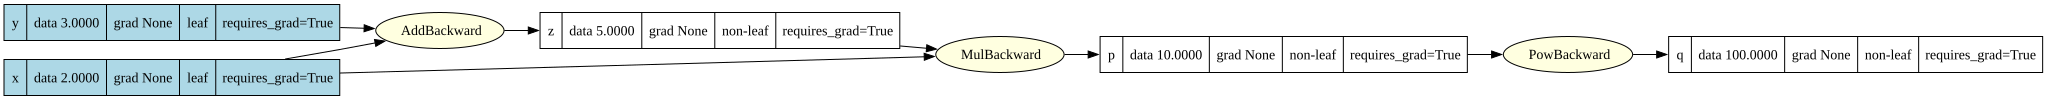

In [63]:
dot

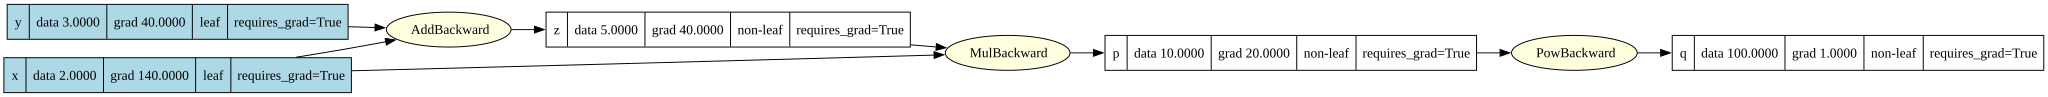

In [64]:
q.grad = 1.0
q._backward()
p._backward()
z._backward()

dot2 = draw_dot(q)
dot2.render('graph_after_backward', view=True)
dot2

In [65]:
x = Tensor(-3.0, requires_grad=True)
y = x.relu()
y.grad = 1.0
y._backward()
print(x.grad)   # 0.0 ✓ — gradient correctly blocked for negative input

x2 = Tensor(3.0, requires_grad=True)
y2 = x2.relu()
y2.grad = 1.0
y2._backward()
print(x2.grad)  # 1.0 ✓ — gradient passes through unchanged for positive input

x3 = Tensor(0.6, requires_grad=True)
y3 = x3.tanh()
y3.grad = 1.0
y3._backward()
print(x3.grad)  # should equal 1 - tanh(0.6)**2

import math
expected = 1 - math.tanh(0.6)**2
print(expected)  # compare — should match exactly

0
1.0
0.7115777625872228
0.7115777625872228


In [66]:
a = Tensor(2.0, label="a", requires_grad=True)
b = Tensor(-3.0, label="b", requires_grad=True)
c = Tensor(10.0, label="c", requires_grad=True)
e = a * b; e.label = "e"
d = e + c; d.label = "d"
f = Tensor(-2.0, label="f", requires_grad=True)
L = d * f; L.label = "L"
L

Tensor(data=-8.0, grad=None, requires_grad=True, is_leaf=False, grad_fn=<MulBackward>)

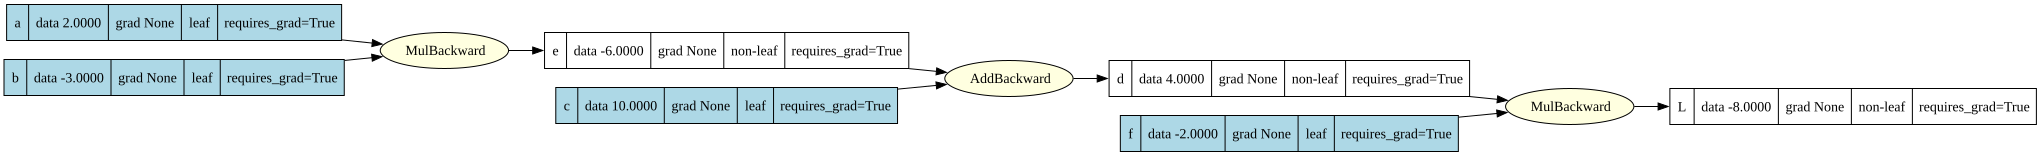

In [67]:
dot = draw_dot(L)
dot

In [68]:
L.grad = 1.0
L._backward()   # sets d.grad, f.grad
d._backward()   # sets e.grad, c.grad
e._backward()   # sets a.grad, b.grad

print(a.grad, b.grad, c.grad, d.grad, e.grad, f.grad)

6.0 -4.0 -2.0 -2.0 -2.0 4.0


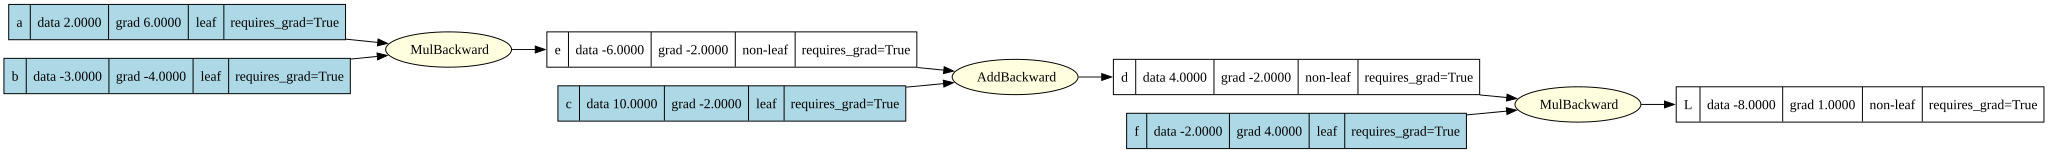

In [69]:
dot = draw_dot(L)
dot

In [70]:
def trace(root):
    nodes, edges = set(), set()
    def build(v):
        if v not in nodes:
            nodes.add(v)
            for child in v._prev:
                edges.add((child, v))
                build(child)
    build(root)
    return nodes, edges

def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        grad_str = f"{n.grad:.4f}" if n.grad is not None else "None"
        leaf_str = "leaf" if n.is_leaf else "non-leaf"

        label = (f"{{ {n.label or ''} | data {n.data:.4f} | grad {grad_str} "
                  f"| {leaf_str} | requires_grad={n.requires_grad} }}")

        fillcolor = "lightblue" if n.is_leaf else "white"

        dot.node(name=uid, label=label, shape='record',
                  style='filled', fillcolor=fillcolor)

        if not n.is_leaf and n.grad_fn is not None:
            op_uid = uid + n._op

            # KEY CHANGE: decide what to show based on whether backward
            # has actually run for this node yet, not just whether it exists
            backward_has_run = n.grad is not None

            if backward_has_run:
                op_label = str(n.grad_fn)      # e.g. "<MulBackward>"
                op_color = 'lightyellow'
            else:
                op_label = f"<{n._op}>"        # e.g. "<*>"  — just the forward symbol
                op_color = 'lightgray'         # visually distinct: "not yet backpropped"

            dot.node(name=op_uid, label=op_label, shape='ellipse',
                      style='filled', fillcolor=op_color)
            dot.edge(op_uid, uid)

    for n1, n2 in edges:
        dot.edge(str(id(n1)), str(id(n2)) + n2._op)

    return dot

In [71]:
a = Tensor(2.0, label="a", requires_grad=True)
b = Tensor(-3.0, label="b", requires_grad=True)
c = Tensor(10.0, label="c", requires_grad=True)
e = a * b; e.label = "e"
d = e + c; d.label = "d"
f = Tensor(-2.0, label="f", requires_grad=True)
L = d * f; L.label = "L"
L

Tensor(data=-8.0, grad=None, requires_grad=True, is_leaf=False, grad_fn=<MulBackward>)

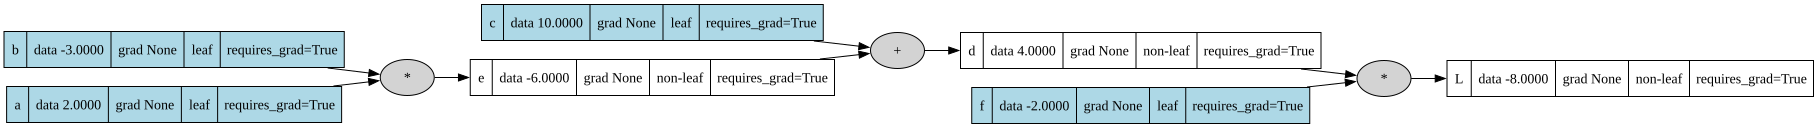

In [72]:
dot_before = draw_dot(L)
dot_before

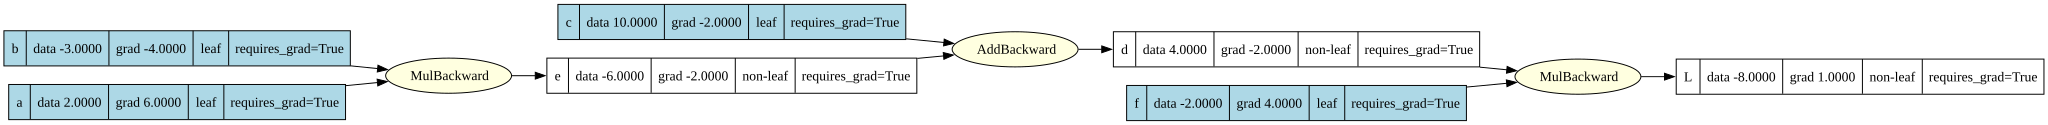

In [73]:
L.grad = 1.0
L._backward()
d._backward()
e._backward()

dot_after = draw_dot(L)
dot_after 

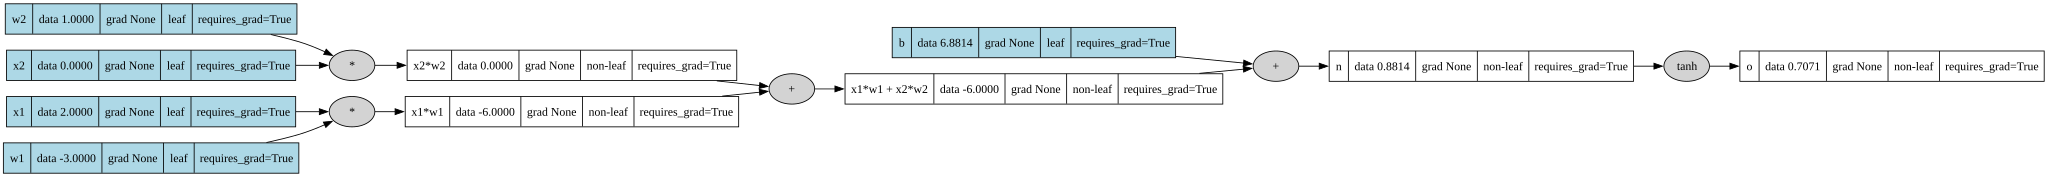

In [74]:
# inputs x1, x2
x1 = Tensor(2.0, label='x1', requires_grad=True)
x2 = Tensor(0.0, label='x2', requires_grad=True)
# weights w1, w2
w1 = Tensor(-3.0, label='w1', requires_grad=True)
w2 = Tensor(1.0, label='w2', requires_grad=True)
# bias of the neuron
b = Tensor(6.8813735870195432, label='b', requires_grad=True)
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

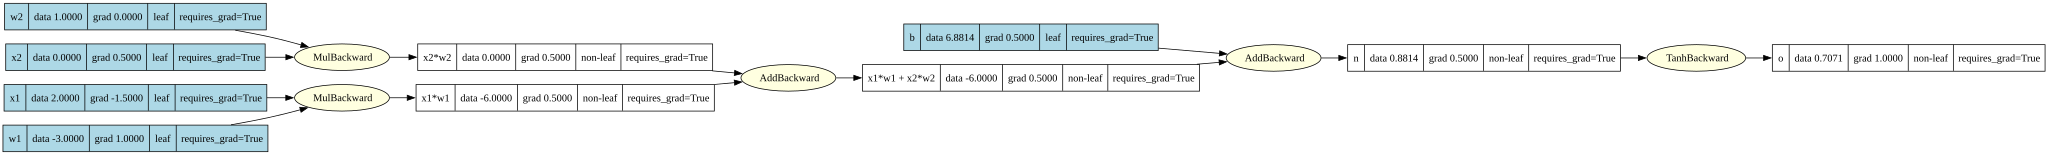

In [75]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

draw_dot(o)

In [76]:
def draw_dot(root):
    dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'})

    nodes, edges = trace(root)

    for n in nodes:
        uid = str(id(n))

        grad_str = f"{n.grad:.4f}" if n.grad is not None else "None"
        leaf_str = "leaf" if n.is_leaf else "non-leaf"

        label = (f"{{ {n.label or ''} | data {n.data:.4f} | grad {grad_str} "
                  f"| {leaf_str} | requires_grad={n.requires_grad} }}")

        fillcolor = "lightblue" if n.is_leaf else "white"

        dot.node(name=uid, label=label, shape='record',
                  style='filled', fillcolor=fillcolor)

        if not n.is_leaf and n.grad_fn is not None:
            op_uid = uid + n._op
            backward_has_run = n.grad is not None

            if backward_has_run:
                op_label = str(n.grad_fn)
                op_color = 'lightyellow'
            else:
                op_label = f"<{n._op}>"
                op_color = 'lightgray'

            dot.node(name=op_uid, label=op_label, shape='ellipse',
                      style='filled', fillcolor=op_color)
            dot.edge(op_uid, uid)

    for n1, n2 in edges:
        op_uid = str(id(n2)) + n2._op

        gradient_reached_child = n1.grad is not None

        if gradient_reached_child:
            dot.edge(str(id(n1)), op_uid, color='red', style='bold',
                      label='grad', dir='back')
        else:
            dot.edge(str(id(n1)), op_uid)

    return dot

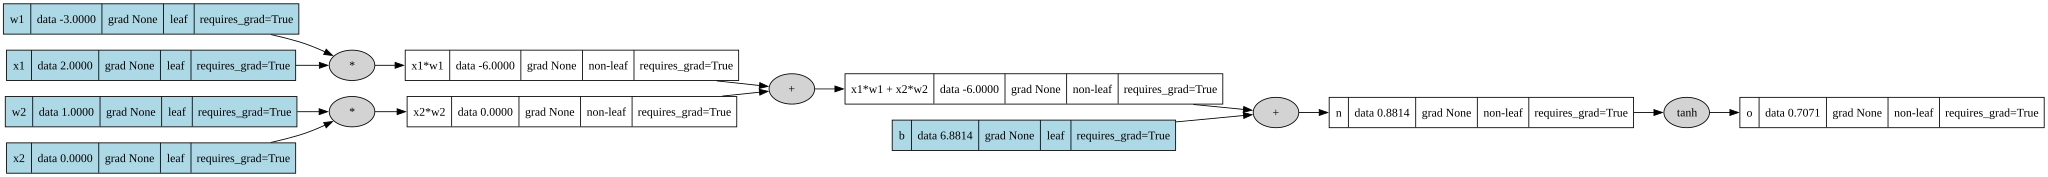

In [77]:
# inputs x1, x2
x1 = Tensor(2.0, label='x1', requires_grad=True)
x2 = Tensor(0.0, label='x2', requires_grad=True)
# weights w1, w2
w1 = Tensor(-3.0, label='w1', requires_grad=True)
w2 = Tensor(1.0, label='w2', requires_grad=True)
# bias of the neuron
b = Tensor(6.8813735870195432, label='b', requires_grad=True)
# x1*w1 + x2*w2 + b
x1w1 = x1 * w1; x1w1.label = 'x1*w1'
x2w2 = x2 * w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'
draw_dot(o)

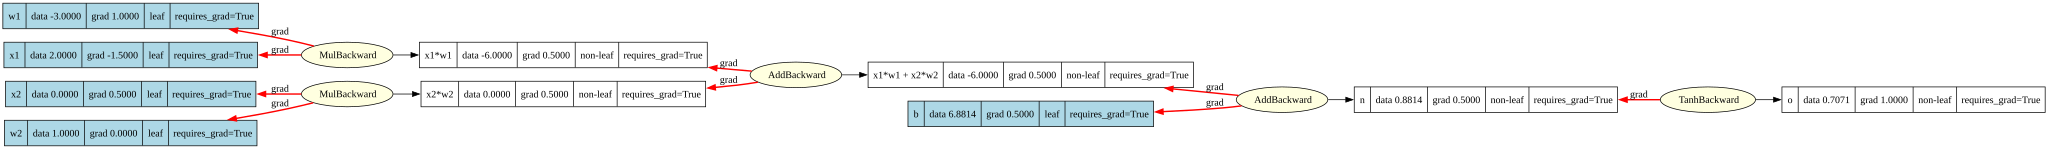

In [78]:
o.grad = 1.0
o._backward()
n._backward()
x1w1x2w2._backward()
x1w1._backward()
x2w2._backward()

draw_dot(o)

In [79]:
import math

def sigmoid(x):
    return 1 / (1 + math.exp(-x))

def sigmoid_deriv(x):
    s = sigmoid(x)
    return s * (1 - s)

x = 0.5
h = 1e-6
numerical = (sigmoid(x + h) - sigmoid(x - h)) / (2 * h)
analytical = sigmoid_deriv(x)
print(numerical, analytical)   # should match to ~6 decimal places

0.23500371221230054 0.2350037122015945


In [80]:
class AddBackward:
    def __repr__(self):
        return "<AddBackward>"

class MulBackward:
    def __repr__(self):
        return "<MulBackward>"

class PowBackward:
    def __repr__(self):
        return "<PowBackward>"
    
class NegBackward:
    def __repr__(self):
        return "<NegBackward>"
    
class SubBackward:
    def __repr__(self):
        return "<SubBackward>"
    
class ReLUBackward:
    def __repr__(self):
        return "<ReLUBackward>"
    
class LeakyReLUBackward:
    def __repr__(self):
        return "<LeakyReLUBackward>"

class TanhBackward:
    def __repr__(self):
        return "<TanhBackward>"
    
class ExpBackward:
    def __repr__(self):
        return "<ExpBackward>"
    
class SigmoidBackward:
    def __repr__(self):
        return "<SigmoidBackward>"
    
class GeLUBackward:
    def __repr__(self):
        return "<GeLUBackward>"

class Tensor:
    def __init__(self, data, _children=(), _op="", label="", requires_grad=False):
        self.data = data
        self._prev = set(_children)
        self._op = _op              # the op that produced this node (for debugging/graphviz)
        self.label = label
        self.grad = None            # None until first backward pass — distinguishes
                                    
        self._backward = lambda: None  # closure that knows how to propagate grad
                                        # to this tensor's children; set by each op
        self.requires_grad = requires_grad
        self.grad_fn = None         # None for leaves; set by each op for non-leaves

    @property
    def is_leaf(self):
        # A leaf is a tensor with no children — i.e. created directly by the user,
        # not produce
        return len(self._prev) == 0

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data + other.data, _children=(self, other), _op="+", requires_grad=requires_grad)
        out.grad_fn = AddBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad if other.grad is None else other.grad + out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data * other.data, _children=(self, other), _op="*", requires_grad=requires_grad)
        out.grad_fn = MulBackward()

        def _backward():
            if self.requires_grad:
                self.grad = other.data * out.grad if self.grad is None else self.grad + other.data * out.grad
            if other.requires_grad:
                other.grad = self.data * out.grad if other.grad is None else other.grad + self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __pow__(self, other):
        if not isinstance(other, (int, float)):
            raise TypeError(f"Exponent must be int or float, got {type(other).__name__}")

        out = Tensor(self.data ** other, _children=(self,), _op="**", requires_grad=self.requires_grad)
        out.grad_fn = PowBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * other * self.data ** (other - 1)
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        out = Tensor(-1 * self.data, _children=(self,), _op="-", requires_grad=self.requires_grad)
        out.grad_fn = NegBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad * -1 if self.grad is None else self.grad + out.grad * -1
        out._backward = _backward
        return out
    
    def __sub__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad
        out = Tensor(self.data - other.data, _children=(self, other), _op="-", requires_grad=requires_grad)
        out.grad_fn = SubBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad * -1 if other.grad is None else other.grad + (out.grad * -1)
        out._backward = _backward
        return out  

    def __rsub__(self, other):
        return self.__sub__(other)    

    def __truediv__(self, other):
        pass
        
    def __rtruediv__(self, other):
        pass

    # Activation functions
    def tanh(self):
        x = self.data 
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Tensor(data=t, _children=(self, ), _op="tanh", requires_grad=self.requires_grad)
        out.grad_fn = TanhBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad * (1 - t**2) if self.grad is None else self.grad + out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def relu(self):
        out = Tensor(0 if self.data < 0 else self.data, (self, ), "Relu", requires_grad=self.requires_grad)
        out.grad_fn = ReLUBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad if self.data > 0 else 0
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out
    
    def leaky_relu(self, alpha=0.01):
        out = Tensor(alpha*self.data if self.data <= 0 else self.data, (self, ), "LeakyRelu", requires_grad=self.requires_grad)
        out.grad_fn = LeakyReLUBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad if self.data > 0 else alpha * out.grad 
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out

    def sigmoid(self):
        sigmoid = 1 / (1 + math.exp(-self.data))
        out = Tensor(sigmoid, (self, ), "Sigmoid", requires_grad=self.requires_grad)
        out.grad_fn = SigmoidBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * out.data * (1 - out.data)
                self.grad = local_grad if self.grad is None else self.grad + local_grad

        out._backward = _backward
        return out
            
    def exp(self):
        pass

    def log(self):
        ...

    def gelu(self):
        ...

    def softmax(self):
        ...

    def __repr__(self):
        return (f"Tensor(data={self.data}, grad={self.grad}, "
                f"requires_grad={self.requires_grad}, is_leaf={self.is_leaf}, "
                f"grad_fn={self.grad_fn})")

In [81]:
x = Tensor(0.5, requires_grad=True)
y = x.sigmoid()
y.grad = 1.0
y._backward()

import math
s = 1 / (1 + math.exp(-0.5))
expected = s * (1 - s)
print(x.grad, expected)   # should match exactly

0.2350037122015945 0.2350037122015945


In [82]:
a = Tensor(2.0, requires_grad=True, label='a')
b = Tensor(-3.0, requires_grad=True, label='b')

c = a * b          # c = -6.0
d = c + a           # d = -4.0
e = -d              # e = 4.0
f = e ** 2          # f = 16.0
g = f.relu()        # g = 16.0
h = g.leaky_relu()  # h = 16.0
i = h.tanh()        # i = tanh(16.0) ≈ 1.0
L = i.sigmoid()     # L = sigmoid(tanh(16.0)) ≈ 0.7311

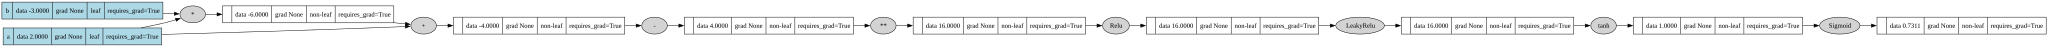

In [83]:
draw_dot(L)

In [84]:
L.grad = 1.0
L._backward()   # -> i.grad

In [85]:
i._backward()   # -> h.grad
h._backward()   # -> g.grad
g._backward()   # -> f.grad
f._backward()   # -> e.grad
e._backward()   # -> d.grad
d._backward()   # -> c.grad, a.grad (first contribution)
c._backward()   # -> a.grad (second contribution, accumulates), b.grad

print(a.grad, b.grad)

1.5925934625847445e-13 -1.5925934625847443e-13


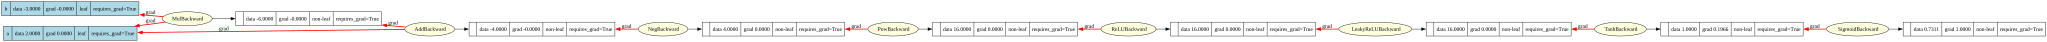

In [86]:
draw_dot(L)

In [ ]:
class AddBackward:
    def __repr__(self):
        return "<AddBackward>"

class MulBackward:
    def __repr__(self):
        return "<MulBackward>"

class PowBackward:
    def __repr__(self):
        return "<PowBackward>"
    
class NegBackward:
    def __repr__(self):
        return "<NegBackward>"

class DivBackward:
    def __repr__(self):
        return "<DivBackward>"
    
class SubBackward:
    def __repr__(self):
        return "<SubBackward>"
    
class ReLUBackward:
    def __repr__(self):
        return "<ReLUBackward>"
    
class LeakyReLUBackward:
    def __repr__(self):
        return "<LeakyReLUBackward>"

class TanhBackward:
    def __repr__(self):
        return "<TanhBackward>"
    
class ExpBackward:
    def __repr__(self):
        return "<ExpBackward>"
    
class SigmoidBackward:
    def __repr__(self):
        return "<SigmoidBackward>"

class LogBackward:
    def __repr__(self):
        return "<LogBackward>"
    
class GeLUBackward:
    def __repr__(self):
        return "<GeLUBackward>"

class Tensor:
    def __init__(self, data, _children=(), _op="", label="", requires_grad=False):
        self.data = data
        self._prev = set(_children)
        self._op = _op              # the op that produced this node (for debugging/graphviz)
        self.label = label
        self.grad = None            # None until first backward pass — distinguishes
                                    
        self._backward = lambda: None  # closure that knows how to propagate grad
                                        # to this tensor's children; set by each op
        self.requires_grad = requires_grad
        self.grad_fn = None         # None for leaves; set by each op for non-leaves

    @property
    def is_leaf(self):
        # A leaf is a tensor with no children — i.e. created directly by the user,
        # not produce
        return len(self._prev) == 0

    def __add__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data + other.data, _children=(self, other), _op="+", requires_grad=requires_grad)
        out.grad_fn = AddBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad if other.grad is None else other.grad + out.grad
        out._backward = _backward
        return out

    def __radd__(self, other):
        return self.__add__(other)

    def __mul__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data * other.data, _children=(self, other), _op="*", requires_grad=requires_grad)
        out.grad_fn = MulBackward()

        def _backward():
            if self.requires_grad:
                self.grad = other.data * out.grad if self.grad is None else self.grad + other.data * out.grad
            if other.requires_grad:
                other.grad = self.data * out.grad if other.grad is None else other.grad + self.data * out.grad
        out._backward = _backward
        return out

    def __rmul__(self, other):
        return self.__mul__(other)

    def __pow__(self, other):
        if not isinstance(other, (int, float)):
            raise TypeError(f"Exponent must be int or float, got {type(other).__name__}")

        out = Tensor(self.data ** other, _children=(self,), _op="**", requires_grad=self.requires_grad)
        out.grad_fn = PowBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * other * self.data ** (other - 1)
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out
    
    def __neg__(self):
        out = Tensor(-1 * self.data, _children=(self,), _op="-", requires_grad=self.requires_grad)
        out.grad_fn = NegBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad * -1 if self.grad is None else self.grad + out.grad * -1
        out._backward = _backward
        return out
    
    def __sub__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad
        out = Tensor(self.data - other.data, _children=(self, other), _op="-", requires_grad=requires_grad)
        out.grad_fn = SubBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad if self.grad is None else self.grad + out.grad
            if other.requires_grad:
                other.grad = out.grad * -1 if other.grad is None else other.grad + (out.grad * -1)
        out._backward = _backward
        return out  

    def __rsub__(self, other):
        return self.__sub__(other) 
       
    def __truediv__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        requires_grad = self.requires_grad or other.requires_grad

        out = Tensor(self.data / other.data, _children=(self, other), _op="/", requires_grad=requires_grad)
        out.grad_fn = DivBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * (1 / other.data)
                self.grad = local_grad if self.grad is None else self.grad + local_grad
            if other.requires_grad:
                local_grad = out.grad * (-self.data / (other.data ** 2))
                other.grad = local_grad if other.grad is None else other.grad + local_grad
        out._backward = _backward
        return out

    def __rtruediv__(self, other):
        other = other if isinstance(other, Tensor) else Tensor(other)
        return other / self 

    # Activation functions
    def tanh(self):
        x = self.data 
        t = (math.exp(2*x) - 1) / (math.exp(2*x) + 1)
        out = Tensor(data=t, _children=(self, ), _op="tanh", requires_grad=self.requires_grad)
        out.grad_fn = TanhBackward()

        def _backward():
            if self.requires_grad:
                self.grad = out.grad * (1 - t**2) if self.grad is None else self.grad + out.grad * (1 - t**2)
        out._backward = _backward
        return out
    
    def relu(self):
        out = Tensor(0 if self.data < 0 else self.data, (self, ), "Relu", requires_grad=self.requires_grad)
        out.grad_fn = ReLUBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad if self.data > 0 else 0
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out
    
    def leaky_relu(self, alpha=0.01):
        out = Tensor(alpha*self.data if self.data <= 0 else self.data, (self, ), 
                     "LeakyRelu", requires_grad=self.requires_grad)
        out.grad_fn = LeakyReLUBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad if self.data > 0 else alpha * out.grad 
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out

    def sigmoid(self):
        sigmoid = 1 / (1 + math.exp(-self.data))
        out = Tensor(sigmoid, (self, ), "Sigmoid", requires_grad=self.requires_grad)
        out.grad_fn = SigmoidBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * out.data * (1 - out.data)
                self.grad = local_grad if self.grad is None else self.grad + local_grad

        out._backward = _backward
        return out
            
    def exp(self):
        # d/dx(e^x) = e^x — same "expressible via output" property as tanh/sigmoid
        t = math.exp(self.data)
        out = Tensor(t, _children=(self,), _op="exp", requires_grad=self.requires_grad)
        out.grad_fn = ExpBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * out.data   # out.data IS e^x already
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out

    def log(self):
        # natural log; d/dx(ln x) = 1/x — genuinely needs the INPUT, not the output,
        if self.data <= 0:
            raise ValueError(f"log() domain error: input must be > 0, got {self.data}")

        t = math.log(self.data)
        out = Tensor(t, _children=(self,), _op="log", requires_grad=self.requires_grad)
        out.grad_fn = LogBackward()

        def _backward():
            if self.requires_grad:
                local_grad = out.grad * (1 / self.data)
                self.grad = local_grad if self.grad is None else self.grad + local_grad
        out._backward = _backward
        return out

    def gelu(self):
        ...

    def elu(self):
        ...

    def softmax(self):
        ...

    def __repr__(self):
        return (f"Tensor(data={self.data}, grad={self.grad}, "
                f"requires_grad={self.requires_grad}, is_leaf={self.is_leaf}, "
                f"grad_fn={self.grad_fn})")

In [88]:
x = Tensor(2.0, requires_grad=True)
y = Tensor(4.0, requires_grad=True)

z = x / y          # 2/4 = 0.5
z.grad = 1.0

w = 10 / x         # 10/2 = 5.0
print(z.data, w.data)   # 0.5, 5.0

0.5 5.0


In [89]:
z._backward()
x._backward()
y._backward()

print(x.grad, y.grad)

0.25 -0.125


In [90]:
x = Tensor(2.0, requires_grad=True)
y = Tensor(4.0, requires_grad=True)

z = x / y
z.grad = 1.0
z._backward()   # sets x.grad and p.grad (p = y**-1, anonymous)

# find p from z's children (the one that isn't x)
p = [child for child in z._prev if child is not x][0]
p._backward()    # NOW sets y.grad

print(x.grad, y.grad)   # 0.25, and y.grad should be -0.125

0.25 -0.125


In [91]:
z._prev

{Tensor(data=2.0, grad=0.25, requires_grad=True, is_leaf=True, grad_fn=None),
 Tensor(data=4.0, grad=-0.125, requires_grad=True, is_leaf=True, grad_fn=None)}

In [92]:
x = Tensor(2.0, requires_grad=True)
y = Tensor(4.0, requires_grad=True)

z = x / y
z.grad = 1.0
z._backward()      # ONE call — sets BOTH x.grad and y.grad directly

print(x.grad, y.grad)   # 0.25, -0.125

0.25 -0.125


In [93]:
z._prev

{Tensor(data=2.0, grad=0.25, requires_grad=True, is_leaf=True, grad_fn=None),
 Tensor(data=4.0, grad=-0.125, requires_grad=True, is_leaf=True, grad_fn=None)}

In [94]:
x = Tensor(2.0, requires_grad=True)
y = Tensor(4.0, requires_grad=True)
z = x / y
z.grad = 1.0
z._backward()
print(x.grad, y.grad)   # expect 0.25, -0.125

w = 10 / x
w.grad = 1.0
w._backward()
print(x.grad)   # accumulates further: previous 0.25 + (10 * -1/2**2) = 0.25 + (-2.5) = -2.25

0.25 -0.125
-2.25


In [95]:
x

Tensor(data=2.0, grad=-2.25, requires_grad=True, is_leaf=True, grad_fn=None)

In [97]:
x

Tensor(data=2.0, grad=-2.25, requires_grad=True, is_leaf=True, grad_fn=None)

In [98]:
y

Tensor(data=4.0, grad=-0.125, requires_grad=True, is_leaf=True, grad_fn=None)

In [99]:
z

Tensor(data=0.5, grad=1.0, requires_grad=True, is_leaf=False, grad_fn=<DivBackward>)

In [100]:
w

Tensor(data=5.0, grad=1.0, requires_grad=True, is_leaf=False, grad_fn=<DivBackward>)